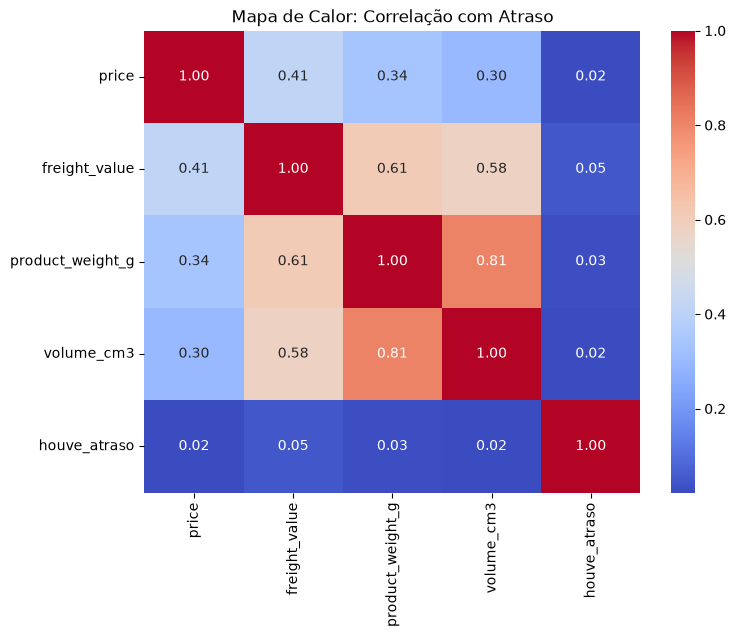

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Leitura da base enriquecida (vinda do 01_prep)
df = pd.read_csv('../data/processed/base_logistica_enriquecida.csv')

# 2. Seleção de variáveis numéricas
cols_numericas = ['price', 'freight_value', 'product_weight_g', 'volume_cm3', 'houve_atraso']

# 3. Cálculo da Matriz de Correlação
# Dica: O valor próximo de 1 indica forte relação, próximo de 0 indica nenhuma.
corr = df[cols_numericas].corr()

# 4. Plotagem do Mapa de Calor
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor: Correlação com Atraso')
plt.show()

# Insight corporativo: Se o 'volume_cm3' ou 'freight_value' tiverem correlação alta,
# eles são os maiores ofensores do SLA e precisam de intervenção imediata.

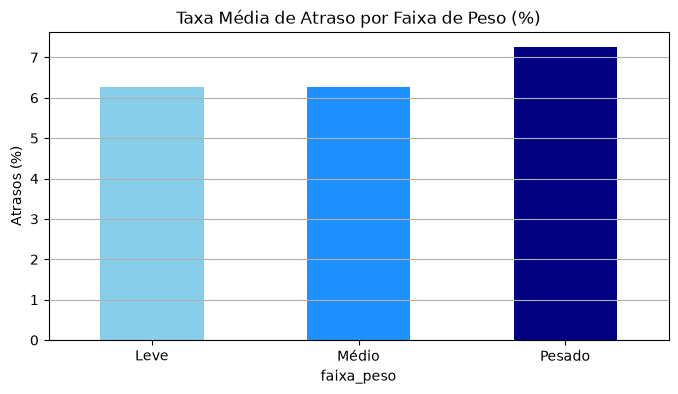

In [ ]:
# 1. Criação de bins (faixas de peso) para análise
# Estamos dividindo os produtos em leves, médios e pesados
df['faixa_peso'] = pd.qcut(df['product_weight_g'], q=3, labels=['Leve', 'Médio', 'Pesado'])

# 2. Cálculo da taxa média de atraso por faixa de peso
analise_peso = df.groupby('faixa_peso')['houve_atraso'].mean() * 100

# 3. Plotagem
plt.figure(figsize=(8, 4))
analise_peso.plot(kind='bar', color=['skyblue', 'dodgerblue', 'navy'])
plt.title('Taxa Média de Atraso por Faixa de Peso (%)')
plt.ylabel('Atrasos (%)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# Insight corporativo: Se a barra 'Pesado' estiver muito mais alta, você provou
# matematicamente que a operação precisa de transportadoras parceiras mais robustas.

In [ ]:
# 1. Cálculo da taxa média de atraso por Estado (customer_state)
# Ordenando do maior risco para o menor
atraso_estado = df.groupby('customer_state')['houve_atraso'].mean().sort_values(ascending=False) * 100

# 2. Mostrando os Top 3 estados com maior risco de quebra de SLA
print("Top 3 Estados com MAIOR Risco Logístico:")
print(atraso_estado.head(3).round(2))

Top 3 Estados com MAIOR Risco Logístico:
customer_state
AL    20.84
MA    18.00
SE    16.27
Name: houve_atraso, dtype: float64
